# Tutorial: FER2013 MediaPipe Landmark Labeling

Audience:
- Researchers in this repo replacing Py-Feat image-based emotion inputs with MediaPipe landmarks.

Prerequisites:
- `.env` contains `HF_TOKEN`.
- The current environment has the research dependencies from `requirements.txt`.

Learning goals:
- Download FER2013 from Hugging Face.
- Extract `468 x/y/z` MediaPipe landmarks for each face.
- Visualize one image, its landmark geometry, and the overlay.
- Write landmark-only `train`, `validation`, and `test` CSVs.


## Outline

1. Load configuration and authenticate with Hugging Face.
2. Download FER2013 and inspect the available splits.
3. Visualize one sample image in three views.
4. Prepare and save landmark-only CSVs.
5. Review manifest and failure counts.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from datasets import load_dataset
from dotenv import load_dotenv
from tqdm.auto import tqdm

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / ".git").exists() and (candidate / "emotional_expressivity").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

REPO_ROOT = find_repo_root(Path.cwd())
DATASET_ID = "AutumnQiu/fer2013"
OUTPUT_DIR = REPO_ROOT / "tmp" / "mediapipe_landmark_emotion" / "dataset"
UPSCALE_SIZE = 224
LANDMARK_COUNT = 468
MAX_PER_SPLIT = 64  # Set to None for a full export.
PREVIEW_IMAGES_PER_SPLIT = 1
EMOTION_LABELS = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "happiness",
    4: "sadness",
    5: "surprise",
    6: "neutral",
}
LANDMARK_COLUMNS = [
    f"lmk{index:03d}_{axis}"
    for index in range(LANDMARK_COUNT)
    for axis in ("x", "y", "z")
]

load_dotenv(REPO_ROOT / ".env")
HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    raise EnvironmentError("HF_TOKEN is missing from the repo .env file.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


/Users/pelmeshek1706/Desktop/projects/airest-face/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/tmp/mediapipe_landmark_emotion/dataset')

In [2]:
def emotion_name(label: int) -> str:
    return EMOTION_LABELS[int(label)]

def sample_id(split_name: str, index: int) -> str:
    return f"{split_name}_{index:06d}"

def rgb_from_dataset_image(image: Any, upscale_size: int = UPSCALE_SIZE) -> np.ndarray:
    pil_image = image.convert("RGB") if hasattr(image, "convert") else image
    image_rgb = np.array(pil_image, dtype=np.uint8)
    if image_rgb.shape[:2] != (upscale_size, upscale_size):
        image_rgb = cv2.resize(image_rgb, (upscale_size, upscale_size), interpolation=cv2.INTER_CUBIC)
    return image_rgb

def normalize_landmark_vector(landmark_vector: np.ndarray) -> np.ndarray:
    coords = landmark_vector.reshape(LANDMARK_COUNT, 3).astype(np.float32)
    coords = coords - coords.mean(axis=0, keepdims=True)
    spans = coords.max(axis=0) - coords.min(axis=0)
    scale = float(np.max(spans))
    if scale < 1e-6:
        scale = 1.0
    return (coords / scale).reshape(-1)

def extract_landmarks(face_mesh: Any, image_rgb: np.ndarray):
    results = face_mesh.process(image_rgb)
    if not results.multi_face_landmarks:
        return None, None
    landmarks = results.multi_face_landmarks[0]
    coords = np.array([[point.x, point.y, point.z] for point in landmarks.landmark[:LANDMARK_COUNT]], dtype=np.float32)
    return coords.reshape(-1), landmarks

def row_from_landmarks(split_name: str, index: int, label: int, normalized_landmarks: np.ndarray) -> dict[str, float | int | str]:
    row = {"sample_id": sample_id(split_name, index), "emotion": int(label), "emotion_name": emotion_name(label)}
    row.update({column_name: float(value) for column_name, value in zip(LANDMARK_COLUMNS, normalized_landmarks.tolist())})
    return row

def resolve_splits(dataset):
    available_splits = list(dataset.keys())
    if {"train", "valid", "test"}.issubset(set(available_splits)):
        return {"train": dataset["train"], "validation": dataset["valid"], "test": dataset["test"]}
    if {"train", "validation", "test"}.issubset(set(available_splits)):
        return {"train": dataset["train"], "validation": dataset["validation"], "test": dataset["test"]}
    raise ValueError(f"Unsupported split layout: {available_splits}")

def draw_landmarks_overlay(image_rgb: np.ndarray, face_landmarks: Any) -> np.ndarray:
    annotated = image_rgb.copy()
    mp.solutions.drawing_utils.draw_landmarks(
        image=annotated,
        landmark_list=face_landmarks,
        connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_tesselation_style(),
    )
    mp.solutions.drawing_utils.draw_landmarks(
        image=annotated,
        landmark_list=face_landmarks,
        connections=mp.solutions.face_mesh.FACEMESH_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_contours_style(),
    )
    return annotated


In [3]:
dataset = load_dataset(DATASET_ID, token=HF_TOKEN)
splits = resolve_splits(dataset)
pd.DataFrame({
    "split": list(splits.keys()),
    "rows": [len(rows) for rows in splits.values()],
})


,split,rows
0,train,28709
1,validation,3589
2,test,3589


## Example visualization

The next cell shows one default training example in three views:
- original upscaled image
- normalized landmark geometry only
- landmarks drawn back on the image


I0000 00:00:1779452265.602126 15461460 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779452265.604012 15461917 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779452265.606966 15461916 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779452265.608401 15461919 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


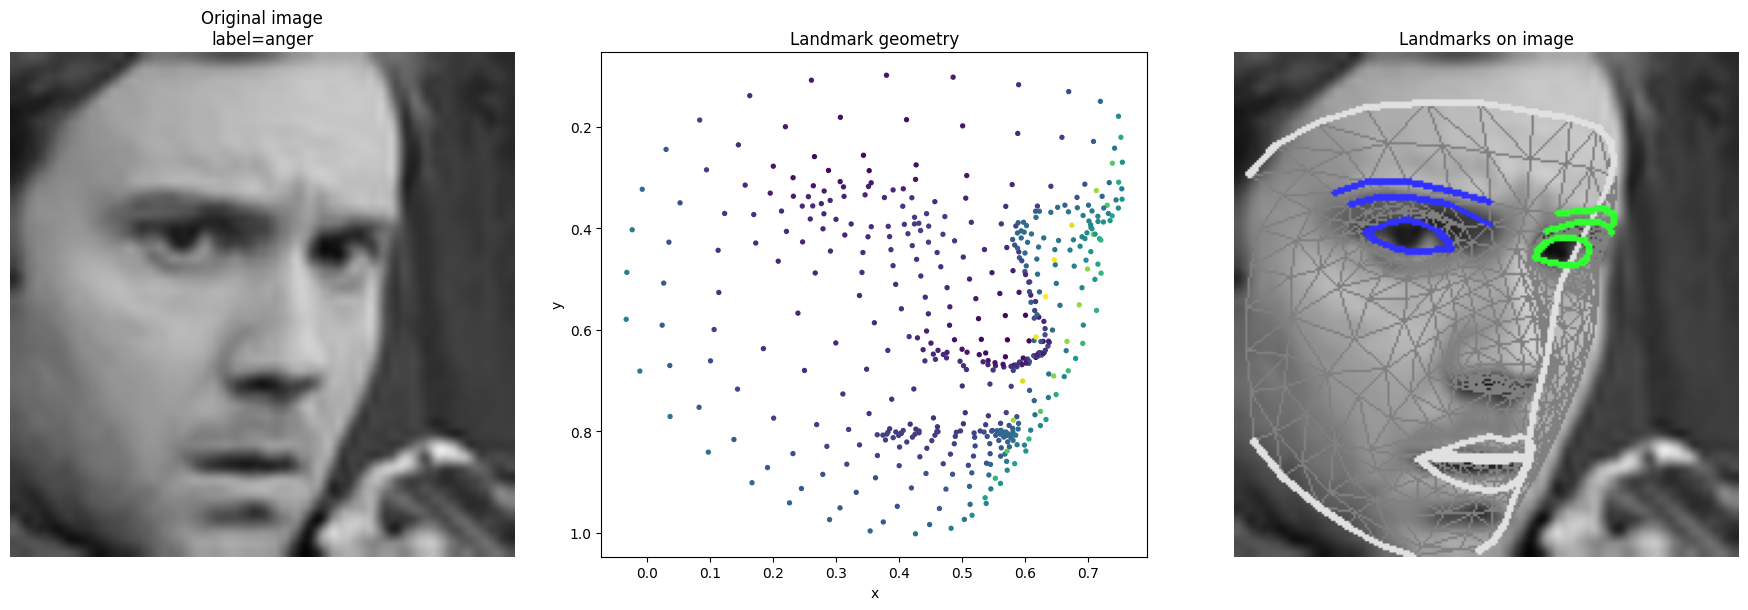

In [4]:
example = splits["train"][0]
example_label = int(example["label"])
example_image_rgb = rgb_from_dataset_image(example["image"])

with mp.solutions.face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=False, min_detection_confidence=0.5) as face_mesh:
    example_landmark_vector, example_face_landmarks = extract_landmarks(face_mesh, example_image_rgb)

if example_landmark_vector is None:
    raise RuntimeError("MediaPipe did not detect a face in the default example image.")

example_landmark_coords = example_landmark_vector.reshape(LANDMARK_COUNT, 3)
example_overlay = draw_landmarks_overlay(example_image_rgb, example_face_landmarks)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(example_image_rgb)
axes[0].set_title(f"Original image\nlabel={emotion_name(example_label)}")
axes[0].axis("off")

axes[1].scatter(example_landmark_coords[:, 0], example_landmark_coords[:, 1], s=8, c=example_landmark_coords[:, 2], cmap="viridis")
axes[1].invert_yaxis()
axes[1].set_title("Landmark geometry")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

axes[2].imshow(example_overlay)
axes[2].set_title("Landmarks on image")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Export landmark-only CSVs

This export keeps only the sample id, label, label name, and `1404` normalized landmark features.
The default run below is a smoke export with `MAX_PER_SPLIT = 64`. Set `MAX_PER_SPLIT = None` in the config cell for a full pass.


In [5]:
preview_dir = OUTPUT_DIR / "previews"
preview_dir.mkdir(parents=True, exist_ok=True)

manifest = {
    "dataset_id": DATASET_ID,
    "upscale_size": UPSCALE_SIZE,
    "landmark_count": LANDMARK_COUNT,
    "max_per_split": MAX_PER_SPLIT,
    "splits": {},
}
failed_rows = []

with mp.solutions.face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=False, min_detection_confidence=0.5) as face_mesh:
    for split_name, split_rows in splits.items():
        limit = min(len(split_rows), MAX_PER_SPLIT) if MAX_PER_SPLIT is not None else len(split_rows)
        rows = []
        saved_preview_paths = []
        failures = 0

        for index in tqdm(range(limit), desc=f"prepare:{split_name}"):
            example = split_rows[index]
            label = int(example["label"])
            sid = sample_id(split_name, index)
            image_rgb = rgb_from_dataset_image(example["image"])
            landmark_vector, face_landmarks = extract_landmarks(face_mesh, image_rgb)

            if landmark_vector is None:
                failures += 1
                failed_rows.append({
                    "sample_id": sid,
                    "split": split_name,
                    "emotion": label,
                    "emotion_name": emotion_name(label),
                    "reason": "no_face_landmarks",
                })
                continue

            normalized = normalize_landmark_vector(landmark_vector)
            rows.append(row_from_landmarks(split_name, index, label, normalized))

            if len(saved_preview_paths) < PREVIEW_IMAGES_PER_SPLIT:
                preview_path = preview_dir / f"{sid}.png"
                cv2.imwrite(str(preview_path), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))
                saved_preview_paths.append(str(preview_path))

        split_df = pd.DataFrame(rows, columns=["sample_id", "emotion", "emotion_name", *LANDMARK_COLUMNS])
        split_csv_path = OUTPUT_DIR / f"{split_name}.csv"
        split_df.to_csv(split_csv_path, index=False)
        manifest["splits"][split_name] = {
            "total_seen": limit,
            "successful_rows": len(split_df),
            "failed_rows": failures,
            "csv_path": str(split_csv_path),
            "preview_paths": saved_preview_paths,
        }

failed_df = pd.DataFrame(failed_rows, columns=["sample_id", "split", "emotion", "emotion_name", "reason"])
failed_df.to_csv(OUTPUT_DIR / "failed_landmarks.csv", index=False)
with (OUTPUT_DIR / "manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)
    handle.write("\n")

pd.DataFrame([
    {"split": split_name, **split_manifest}
    for split_name, split_manifest in manifest["splits"].items()
])[ ["split", "total_seen", "successful_rows", "failed_rows", "csv_path"] ]


I0000 00:00:1779452266.013206 15461460 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro


W0000 00:00:1779452266.014528 15461965 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
prepare:train:   0%|          | 0/64 [00:00<?, ?it/s]

W0000 00:00:1779452266.017425 15461965 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
prepare:train:  36%|███▌      | 23/64 [00:00<00:00, 226.67it/s]

prepare:train:  75%|███████▌  | 48/64 [00:00<00:00, 235.02it/s]

prepare:train: 100%|██████████| 64/64 [00:00<00:00, 236.89it/s]

...

prepare:test:   0%|          | 0/64 [00:00<?, ?it/s]

prepare:test:  41%|████      | 26/64 [00:00<00:00, 259.45it/s]

prepare:test:  81%|████████▏ | 52/64 [00:00<00:00, 254.80it/s]

prepare:test: 100%|██████████| 64/64 [00:00<00:00, 250.92it/s]

,split,total_seen,successful_rows,failed_rows,csv_path
0,train,64,57,7,/Users/pelmeshek1706/Desktop/projects/airest-f...
1,validation,64,61,3,/Users/pelmeshek1706/Desktop/projects/airest-f...
2,test,64,52,12,/Users/pelmeshek1706/Desktop/projects/airest-f...


In [6]:
failed_df.head(), json.loads((OUTPUT_DIR / "manifest.json").read_text())


(      sample_id  split  emotion emotion_name             reason
 0  train_000003  train        4      sadness  no_face_landmarks
 1  train_000018  train        6      neutral  no_face_landmarks
 2  train_000023  train        0        anger  no_face_landmarks
 3  train_000038  train        0        anger  no_face_landmarks
 4  train_000045  train        2         fear  no_face_landmarks,
 {'dataset_id': 'AutumnQiu/fer2013',
  'upscale_size': 224,
  'landmark_count': 468,
  'max_per_split': 64,
  'splits': {'train': {'total_seen': 64,
    'successful_rows': 57,
    'failed_rows': 7,
    'csv_path': '/Users/pelmeshek1706/Desktop/projects/airest-face/tmp/mediapipe_landmark_emotion/dataset/train.csv',
    'preview_paths': ['/Users/pelmeshek1706/Desktop/projects/airest-face/tmp/mediapipe_landmark_emotion/dataset/previews/train_000000.png']},
   'validation': {'total_seen': 64,
    'successful_rows': 61,
    'failed_rows': 3,
    'csv_path': '/Users/pelmeshek1706/Desktop/projects/airest-face

The generated CSVs are ready for the training notebook. The expected schema is `sample_id`, `emotion`, `emotion_name`, plus `1404` landmark features.
